In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pd.set_option('display.max_columns',None)
sns.set_theme(style='whitegrid')

In [4]:
df=pd.read_csv('../data/Sample - Superstore.csv',encoding='latin-1')

In [5]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 row")
df.head()

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 row


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
print("===Missing Values===")
print(df.isnull().sum())

print("\n===DataTypes===")
print(df.dtypes)

print("\n=== BASIC STATISTICS ===")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

===Missing Values===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

===DataTypes===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== BASIC 

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [16]:
df['Year']= df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Quarter']=df['Order Date'].dt.quarter
df['Month_Year']=df['Order Date'].dt.to_period('M')


In [19]:
df['Shipping Days']=(df['Ship Date']-df['Order Date']).dt.days

In [22]:
print("=== DATE TYPES AFTER FIX ===")
print(df[['Order Date', 'Ship Date']].dtypes)

=== DATE TYPES AFTER FIX ===
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [23]:
print("\n=== NEW FEATURES SAMPLE ===")
print(df[['Order Date', 'Year', 'Month', 'Quarter', 'Ship_Days']].head())


=== NEW FEATURES SAMPLE ===
  Order Date  Year  Month  Quarter  Ship_Days
0 2016-11-08  2016     11        4          3
1 2016-11-08  2016     11        4          3
2 2016-06-12  2016      6        2          4
3 2015-10-11  2015     10        4          7
4 2015-10-11  2015     10        4          7


In [24]:
print("\n===Yearly Range===")


===Yearly Range===


In [29]:
print("\n=== YEAR RANGE IN DATASET ===")
print(f"From: {df['Order Date'].min()} → To: {df['Order Date'].max()}")


=== YEAR RANGE IN DATASET ===
From: 2014-01-03 00:00:00 → To: 2017-12-30 00:00:00


In [30]:
print(df['Year'].value_counts().sort_index())

Year
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64


In [31]:
monthly_sales=df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year']=monthly_sales['Month_Year'].astype(str)

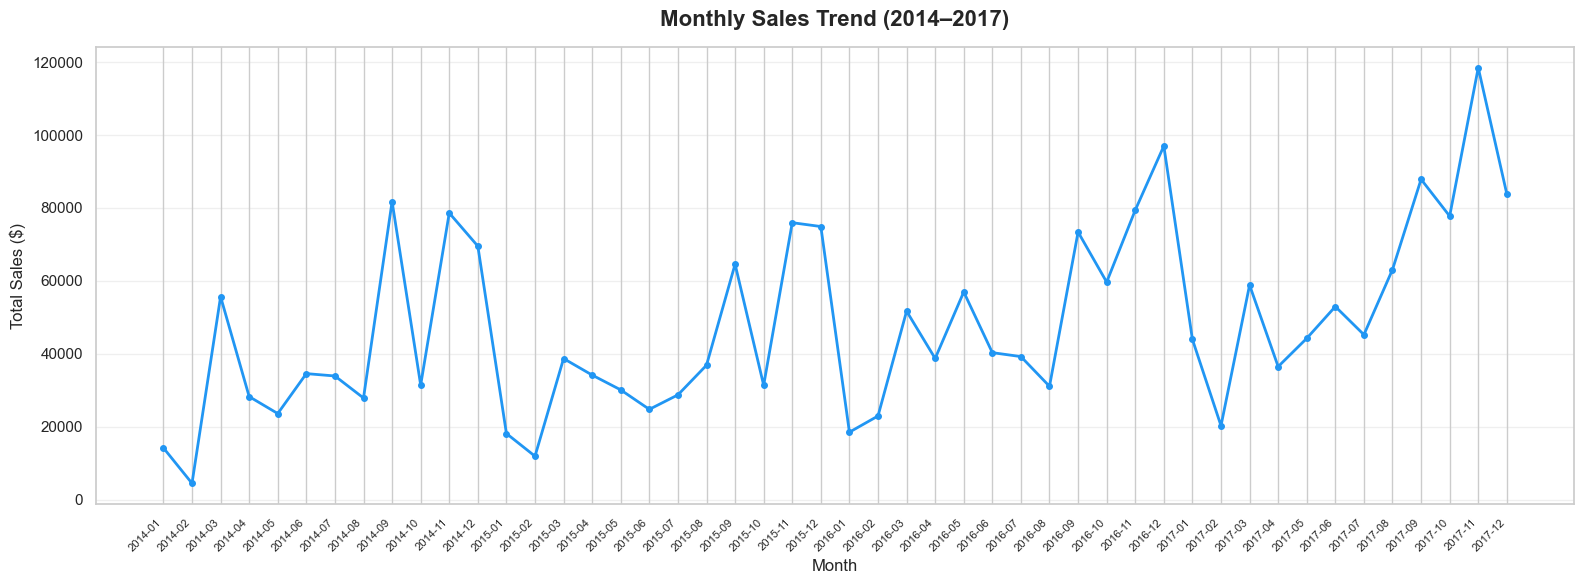

Chart saved to reports/


In [36]:
plt.figure(figsize=(16, 6))
plt.plot(monthly_sales['Month_Year'], 
         monthly_sales['Sales'], 
         color='#2196F3', linewidth=2, marker='o', markersize=4)

plt.title('Monthly Sales Trend (2014–2017)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/01_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to reports/")

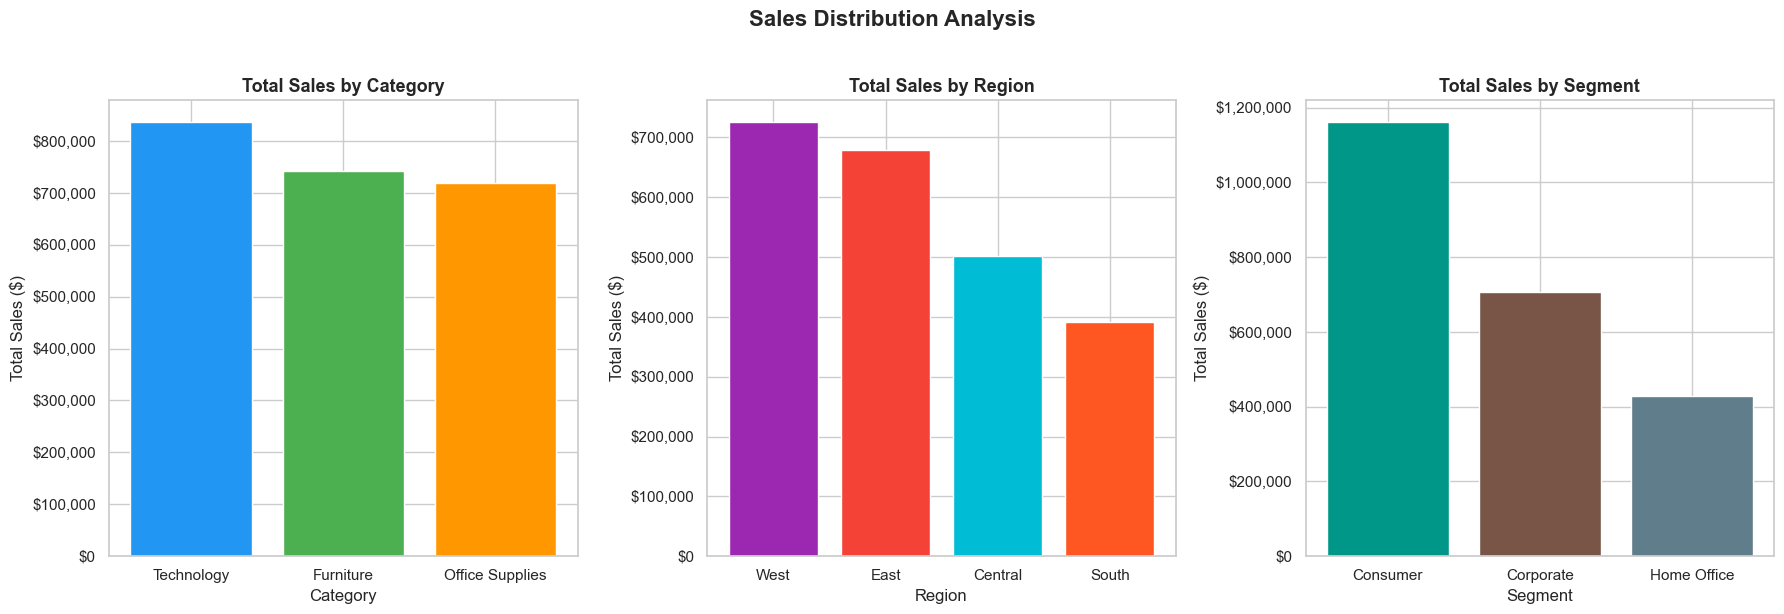

Chart saved to reports/


In [37]:
fig, axes =plt.subplots(1,3, figsize=(18,6))

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(category_sales.index, category_sales.values, color=['#2196F3','#4CAF50','#FF9800'])
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[1].bar(region_sales.index, region_sales.values, color=['#9C27B0','#F44336','#00BCD4','#FF5722'])
axes[1].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Sales ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[2].bar(segment_sales.index, segment_sales.values, color=['#009688','#795548','#607D8B'])
axes[2].set_title('Total Sales by Segment', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Total Sales ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Sales Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/02_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to reports/")


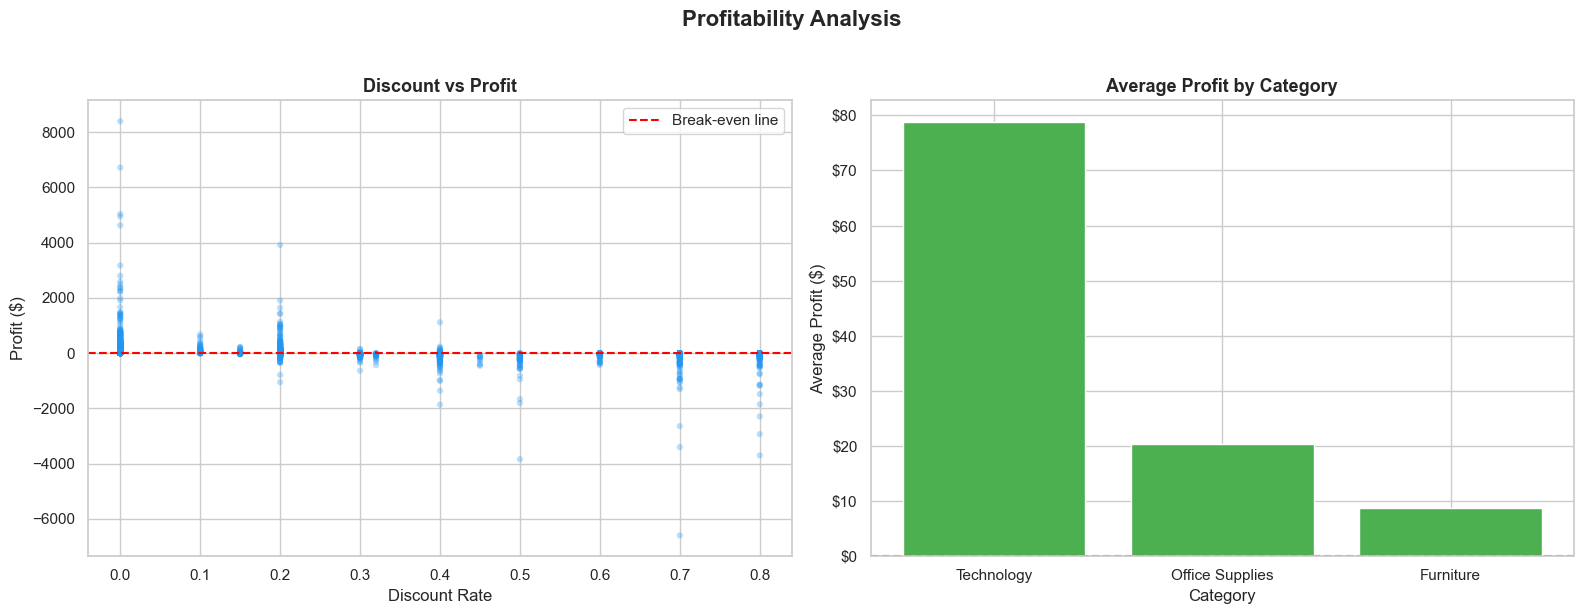

Chart saved to reports/


In [38]:
fig, axes = plt.subplots(1,2 ,figsize=(16,6))
axes[0].scatter(df['Discount'], df['Profit'], 
                alpha=0.3, color='#2196F3', edgecolors='none', s=20)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break-even line')
axes[0].set_title('Discount vs Profit', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].legend()

profit_category = df.groupby('Category')['Profit'].mean().sort_values(ascending=False)
colors = ['#4CAF50' if x > 0 else '#F44336' for x in profit_category.values]
axes[1].bar(profit_category.index, profit_category.values, color=colors)
axes[1].set_title('Average Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Profit ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Profitability Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/03_profitability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to reports/")